# Franklin LIP ca. 719 Ma paleomagnetic pole

## Geologic context

The Franklin large igneous province (LIP) is one of the largest magmatic events
in the geologic record, emplaced across Arctic Laurentia (Victoria Island, Baffin
Island, Devon and Ellesmere islands, and the Thule region of Greenland) as an
extensive swarm of mafic dykes and sills together with the Natkusiak flood
basalts on Victoria Island. Paleomagnetic data place the province at tropical
(near-equatorial) latitudes, and it was emplaced less than two million years
before the onset of the Sturtian Snowball Earth glaciation — a temporal relationship
that has motivated the hypothesis that Franklin volcanism could have played a role in triggering global
glaciation through enhanced weatherability of its Ca–Mg-rich basalts  (Macdonald & Swanson-Hysell, 2023).

This notebook adopts the **grand-mean Franklin paleomagnetic pole of Denyszyn et
al. (2009)** — the value carried in `data/Kringdalen_w_Laurentia.xlsx` and the
Nordic Workshop compilation — and **updates the geochronology** with the
high-precision U-Pb CA-ID-TIMS dates of Pu et al. (2022) and Dufour et al. (2023)
as synthesized by Macdonald & Swanson-Hysell (2023). The pole is currently **hard-coded  rather than recomputed from
site-level data**; rebuilding it from a site-level MagIC compilation of the
constituent studies is left as future work.

## Paleomagnetic and rock magnetic data

Franklin igneous rocks carry a stable, dual-polarity remanence held by magnetite
/ low-Ti titanomagnetite, isolated by stepwise alternating-field and thermal
demagnetization with principal-component analysis. Denyszyn et al. (2009)
reported a **positive baked-contact test** (the characteristic Franklin dyke
direction is recorded in the baked Paleoproterozoic host rock but not in the
distal unbaked host), establishing the remanence as primary and acquired at the
time of dyke emplacement.

The pole used here is Denyszyn et al. (2009) Table 3 entry **"D+09can"**
(Victoria Island–Baffin lavas and intrusions, "site-filtered previous studies"),
a grand mean of the unrotated North American Franklin data (28 normal- + 28
reverse-polarity site results = 56) at **6.7°N, 162.1°E, A95 = 3.0°**. This is
distinct from Denyszyn et al.'s alternative "Canada and Greenland" grand mean
(8.4°N, 163.8°E) that additionally restores hypothesized Cenozoic block rotations
of Greenland and an "Ellesmere microplate"; the compilation (and Macdonald &
Swanson-Hysell, 2023) use the 6.7°N / 162.1°E value.

## Age constraints

The Franklin event was originally dated by U-Pb baddeleyite to *ca.* 723 (+4/−2)
Ma (Heaman et al., 1992), with Denyszyn et al. (2009) reporting baddeleyite dates
of *ca.* 721–712 Ma on their dated dykes. These have been **superseded by
high-precision U-Pb CA-ID-TIMS zircon geochronology** showing rapid emplacement
of the main pulse:

- **Pu et al. (2022)** dated zircon and baddeleyite from differentiated Franklin
  sills across Arctic Canada and found rapid emplacement of the main pulse
  between **719.86 ± 0.21 Ma and 718.61 ± 0.30 Ma** — an earlier, less voluminous
  "Type-1" pulse (719.86 ± 0.21 Ma) followed by the more voluminous "Type-2"
  magmatism (dates clustering 719.1–718.3 Ma) — placing Franklin emplacement
  0.9–1.6 Myr before the onset of widespread Sturtian glaciation.
- **Dufour et al. (2023)** added U-Pb CA-ID-TIMS zircon dates from two dykes and
  two sills on Baffin Island and in NW Greenland (dykes crosscutting sills),
  recording magmatic activity over 1.10 ± 0.74 Myr at *ca.* 718 Ma; combined with
  the other high-precision dates they estimate a total Franklin event duration of
  **2.14 ± 0.75 Myr** and a Sturtian onset at 717.19 (+0.26/−0.33) Ma.
- **Macdonald & Swanson-Hysell (2023)** synthesize these results: the main stage
  of Franklin magmatism spans *ca.* 719.1–718.6 Ma. This synthesis involves resampling from the uncertainty of each weighted mean date and determining the minimum and maximum age of these resamples— resulting in a duration estimate of 540,000 years (95% range of 260,000 to 860,000 years).

We therefore adopt a nominal age of **ca. 719 Ma** for the Franklin pole.

## References

### Paleomagnetism

- Denyszyn, S. W., Halls, H. C., Davis, D. W., & Evans, D. A. D. (2009). Paleomagnetism and U-Pb geochronology of Franklin dykes in High Arctic Canada and Greenland: a revised age and paleomagnetic pole constraining block rotations in the Nares Strait region. *Canadian Journal of Earth Sciences*, 46(9), 689–705. https://doi.org/10.1139/E09-042

### Geochronology

- Pu, J. P., Macdonald, F. A., Schmitz, M. D., Rainbird, R. H., Bleeker, W., Peak, B. A., Flowers, R. M., Hoffman, P. F., Rioux, M., & Hamilton, M. A. (2022). Emplacement of the Franklin large igneous province and initiation of the Sturtian Snowball Earth. *Science Advances*, 8(50), eadc9430. https://doi.org/10.1126/sciadv.adc9430
- Dufour, F., Davies, J. H. F. L., Greenman, J. W., Skulski, T., Halverson, G. P., & Stevenson, R. (2023). New U-Pb CA-ID TIMS zircon ages implicate the Franklin LIP as the proximal trigger for the Sturtian Snowball Earth event. *Earth and Planetary Science Letters*, 618, 118259. https://doi.org/10.1016/j.epsl.2023.118259
- Macdonald, F. A., & Swanson-Hysell, N. L. (2023). The Franklin large igneous province and Snowball Earth initiation. *Elements*, 19(5), 296–301. https://doi.org/10.2138/gselements.19.5.296

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Grand-mean pole (hard-coded from Denyszyn et al., 2009)

The pole is the Denyszyn et al. (2009) Table 3 "D+09can" grand mean (Victoria
Island–Baffin lavas and intrusions). The mean direction (declination 289.1°,
inclination 0.6°) is given at the grand-mean reference locality (73.0°N,
275.4°E), as recorded in the Nordic compilation. Following the Nordic convention
for grand-mean ("combined result") poles, N is recorded as a synthetic 1000; the
number of contributing site results is B = 56.

In [2]:
# Denyszyn et al. (2009) grand-mean Franklin pole (D+09can); the value carried in
# data/Kringdalen_w_Laurentia.xlsx and the Nordic compilation.
pole_mean = {'dec': 162.1, 'inc': 6.7, 'alpha95': 3.0, 'n': 56, 'k': 1000.0}
dir_mean = {'dec': 289.1, 'inc': 0.6, 'alpha95': 0.1, 'k': 1000.0}
study_lat, study_lon = 73.0, 275.4   # grand-mean reference locality
B_sites = 56                         # 28 normal + 28 reverse site results
N_samples = 1000                     # synthetic N for the grand mean

print(f"Franklin grand-mean pole: {pole_mean['inc']:.1f}°N, {pole_mean['dec']:.1f}°E, "
      f"A95 = {pole_mean['alpha95']:.1f}°, B = {B_sites} site results (N = {N_samples}, synthetic)")
print(f"Mean direction at {study_lat}°N, {study_lon}°E: "
      f"Dec {dir_mean['dec']:.1f}°, Inc {dir_mean['inc']:.1f}°")

Franklin grand-mean pole: 6.7°N, 162.1°E, A95 = 3.0°, B = 56 site results (N = 1000, synthetic)
Mean direction at 73.0°N, 275.4°E: Dec 289.1°, Inc 0.6°


## Pole on an orthographic map

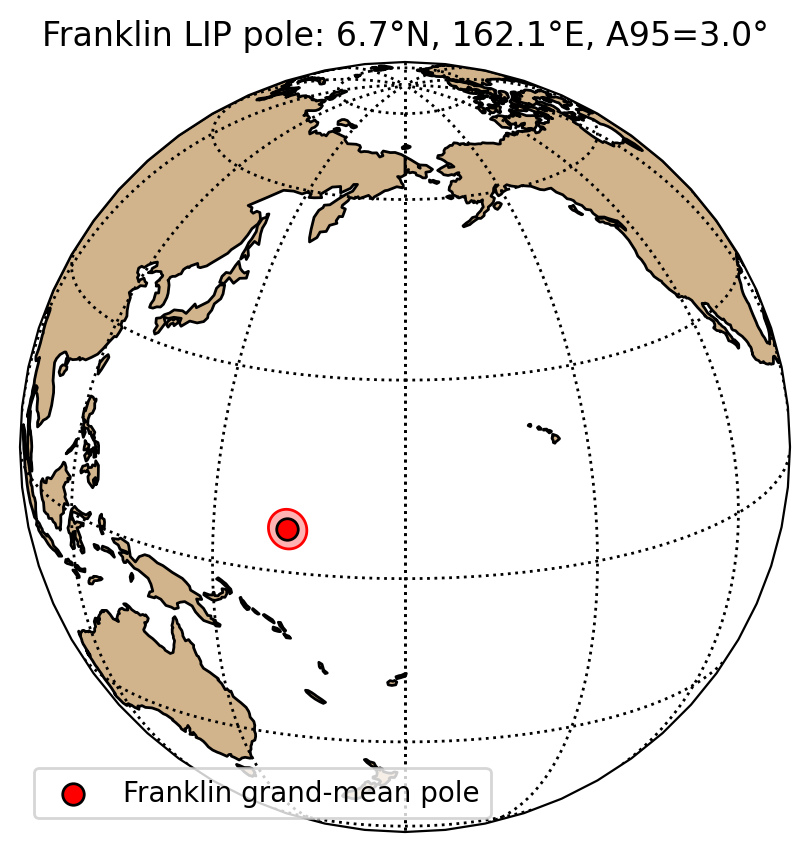

In [3]:
ax = ipmag.make_orthographic_map(central_longitude=180, central_latitude=20, figsize=(5, 5))
ipmag.plot_pole(ax, pole_mean['dec'], pole_mean['inc'], pole_mean['alpha95'],
                color='red', markersize=60, filled_pole=True,
                fill_color='red', fill_alpha=0.3, label='Franklin grand-mean pole')
plt.legend(loc='lower left')
plt.title(f"Franklin LIP pole: {pole_mean['inc']:.1f}°N, {pole_mean['dec']:.1f}°E, "
          f"A95={pole_mean['alpha95']:.1f}°")
plt.show()

## Pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


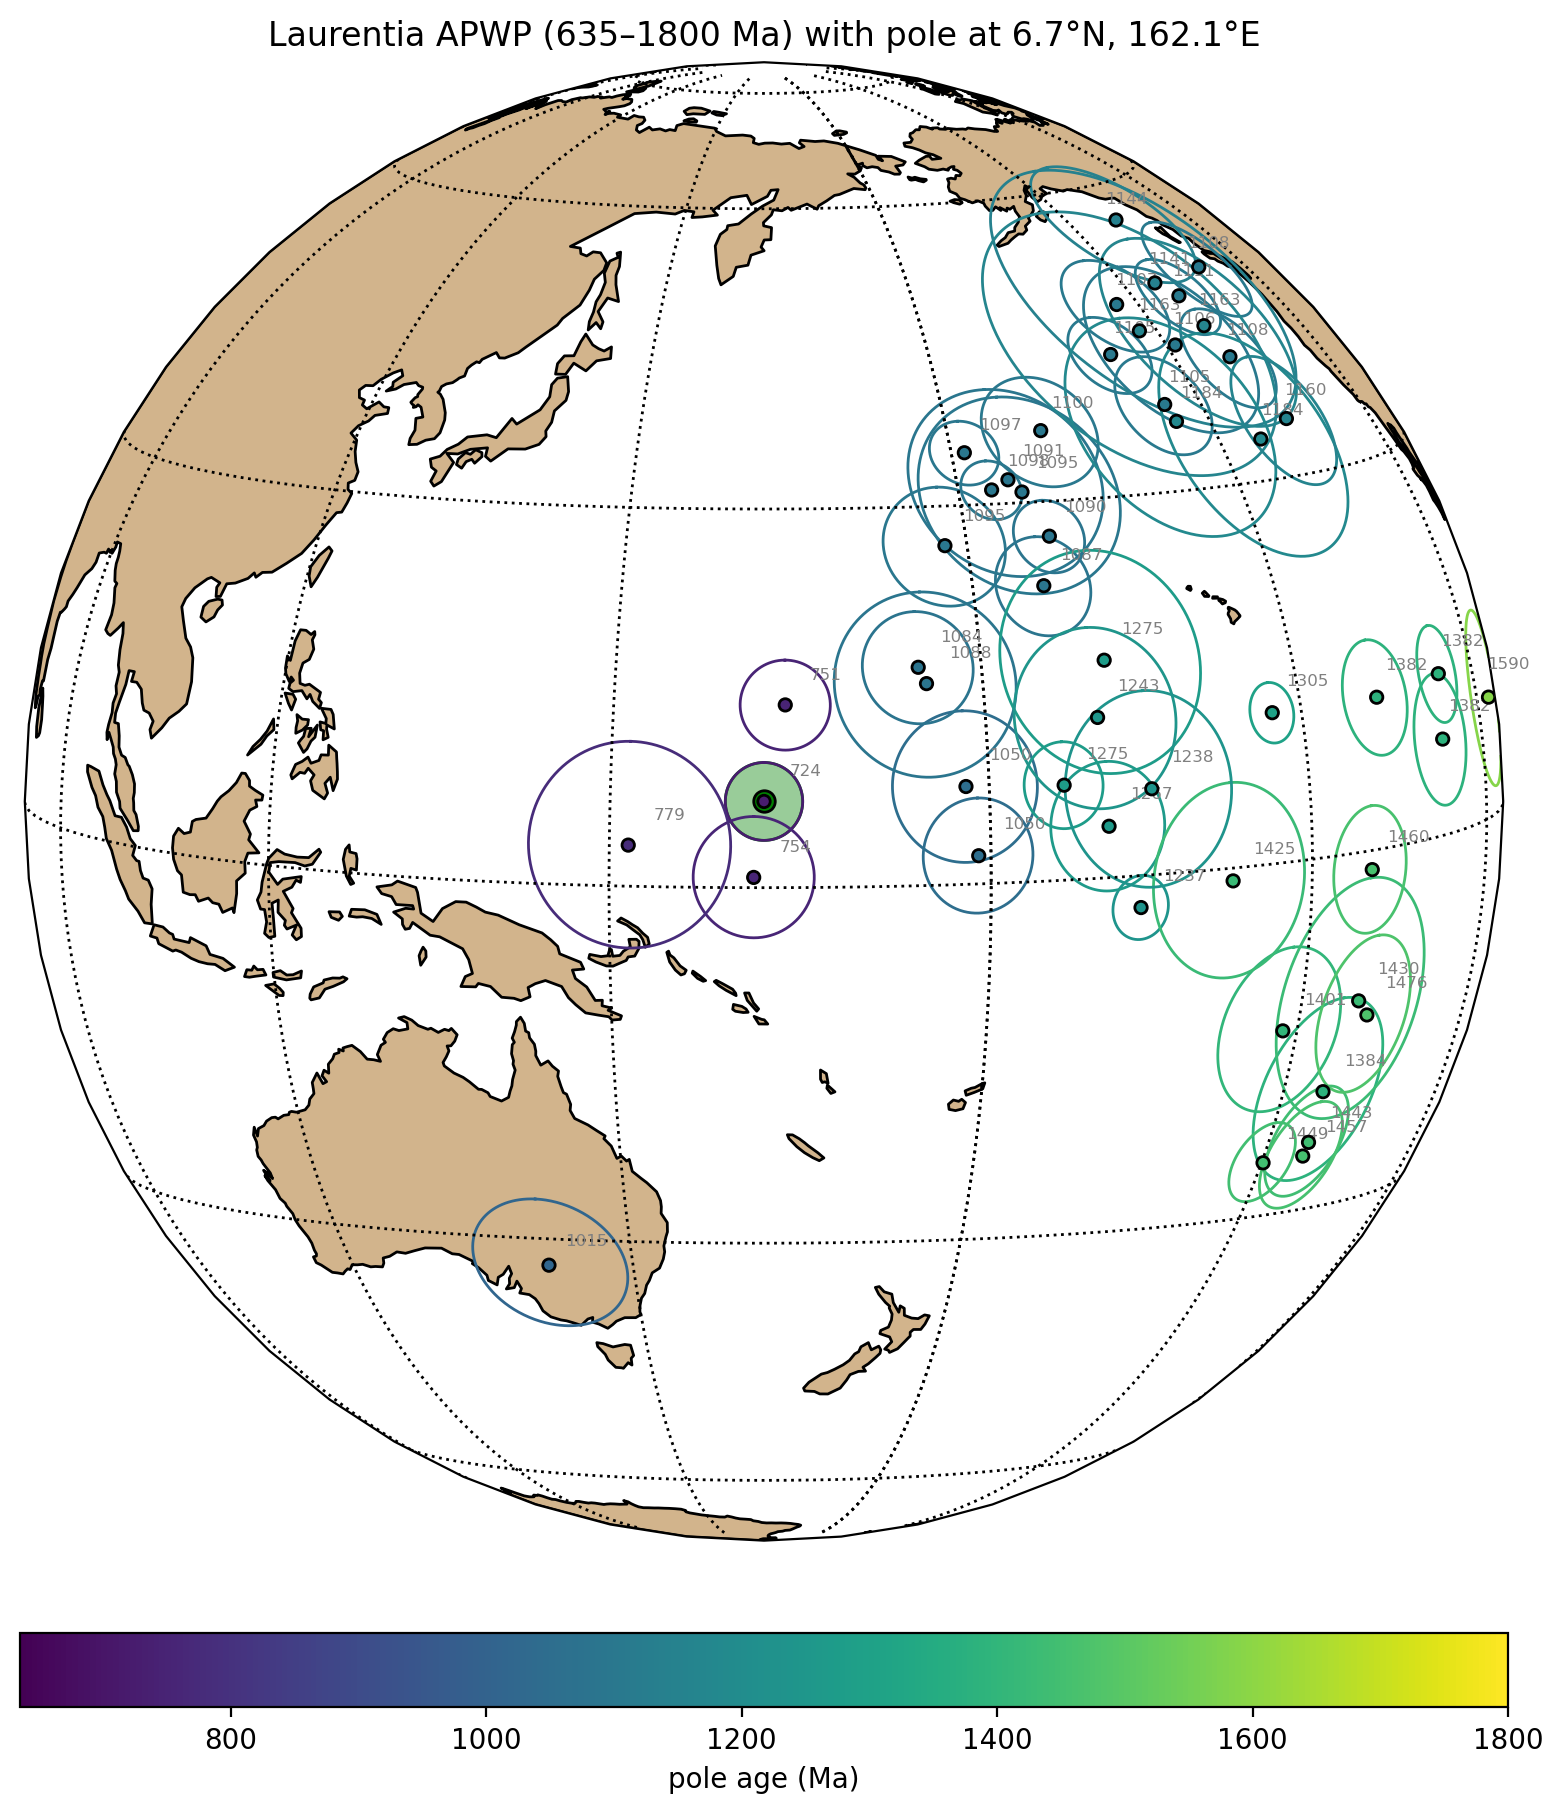

In [4]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], age_min=635, age_max=1800, projection='orthographic', central_longitude=pole_mean['dec'], central_latitude=pole_mean['inc'])
ipmag.plt.show()

## R2: Deenen test

For this grand mean, the Deenen et al. (2011) A95 envelope is evaluated against
the number of contributing site results (B = 56) as an indicative check; the
formal R2 PSV-sampling assessment for the Franklin event would be made from the
site-level VGP distribution if the pole were rebuilt from site data. The
directional Fisher precision and per-site statistics underlying the grand mean
are documented in Denyszyn et al. (2009) and the source studies.

A_95 of 3.0 passes Deenen et al. (2011) criteria of being between 2.4 and 6.5 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

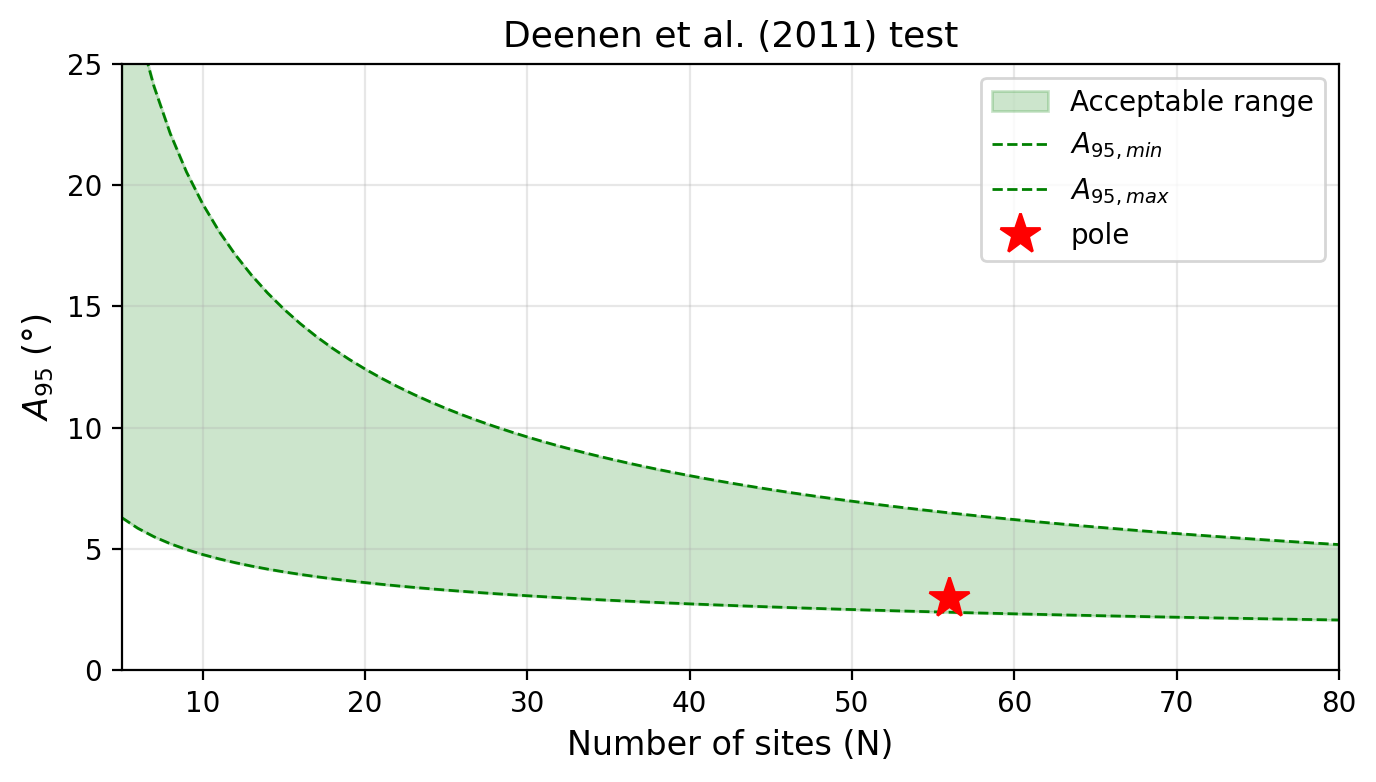

In [5]:
pt.Deenen_test(B_sites, pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## R7: Comparison with younger Laurentia poles

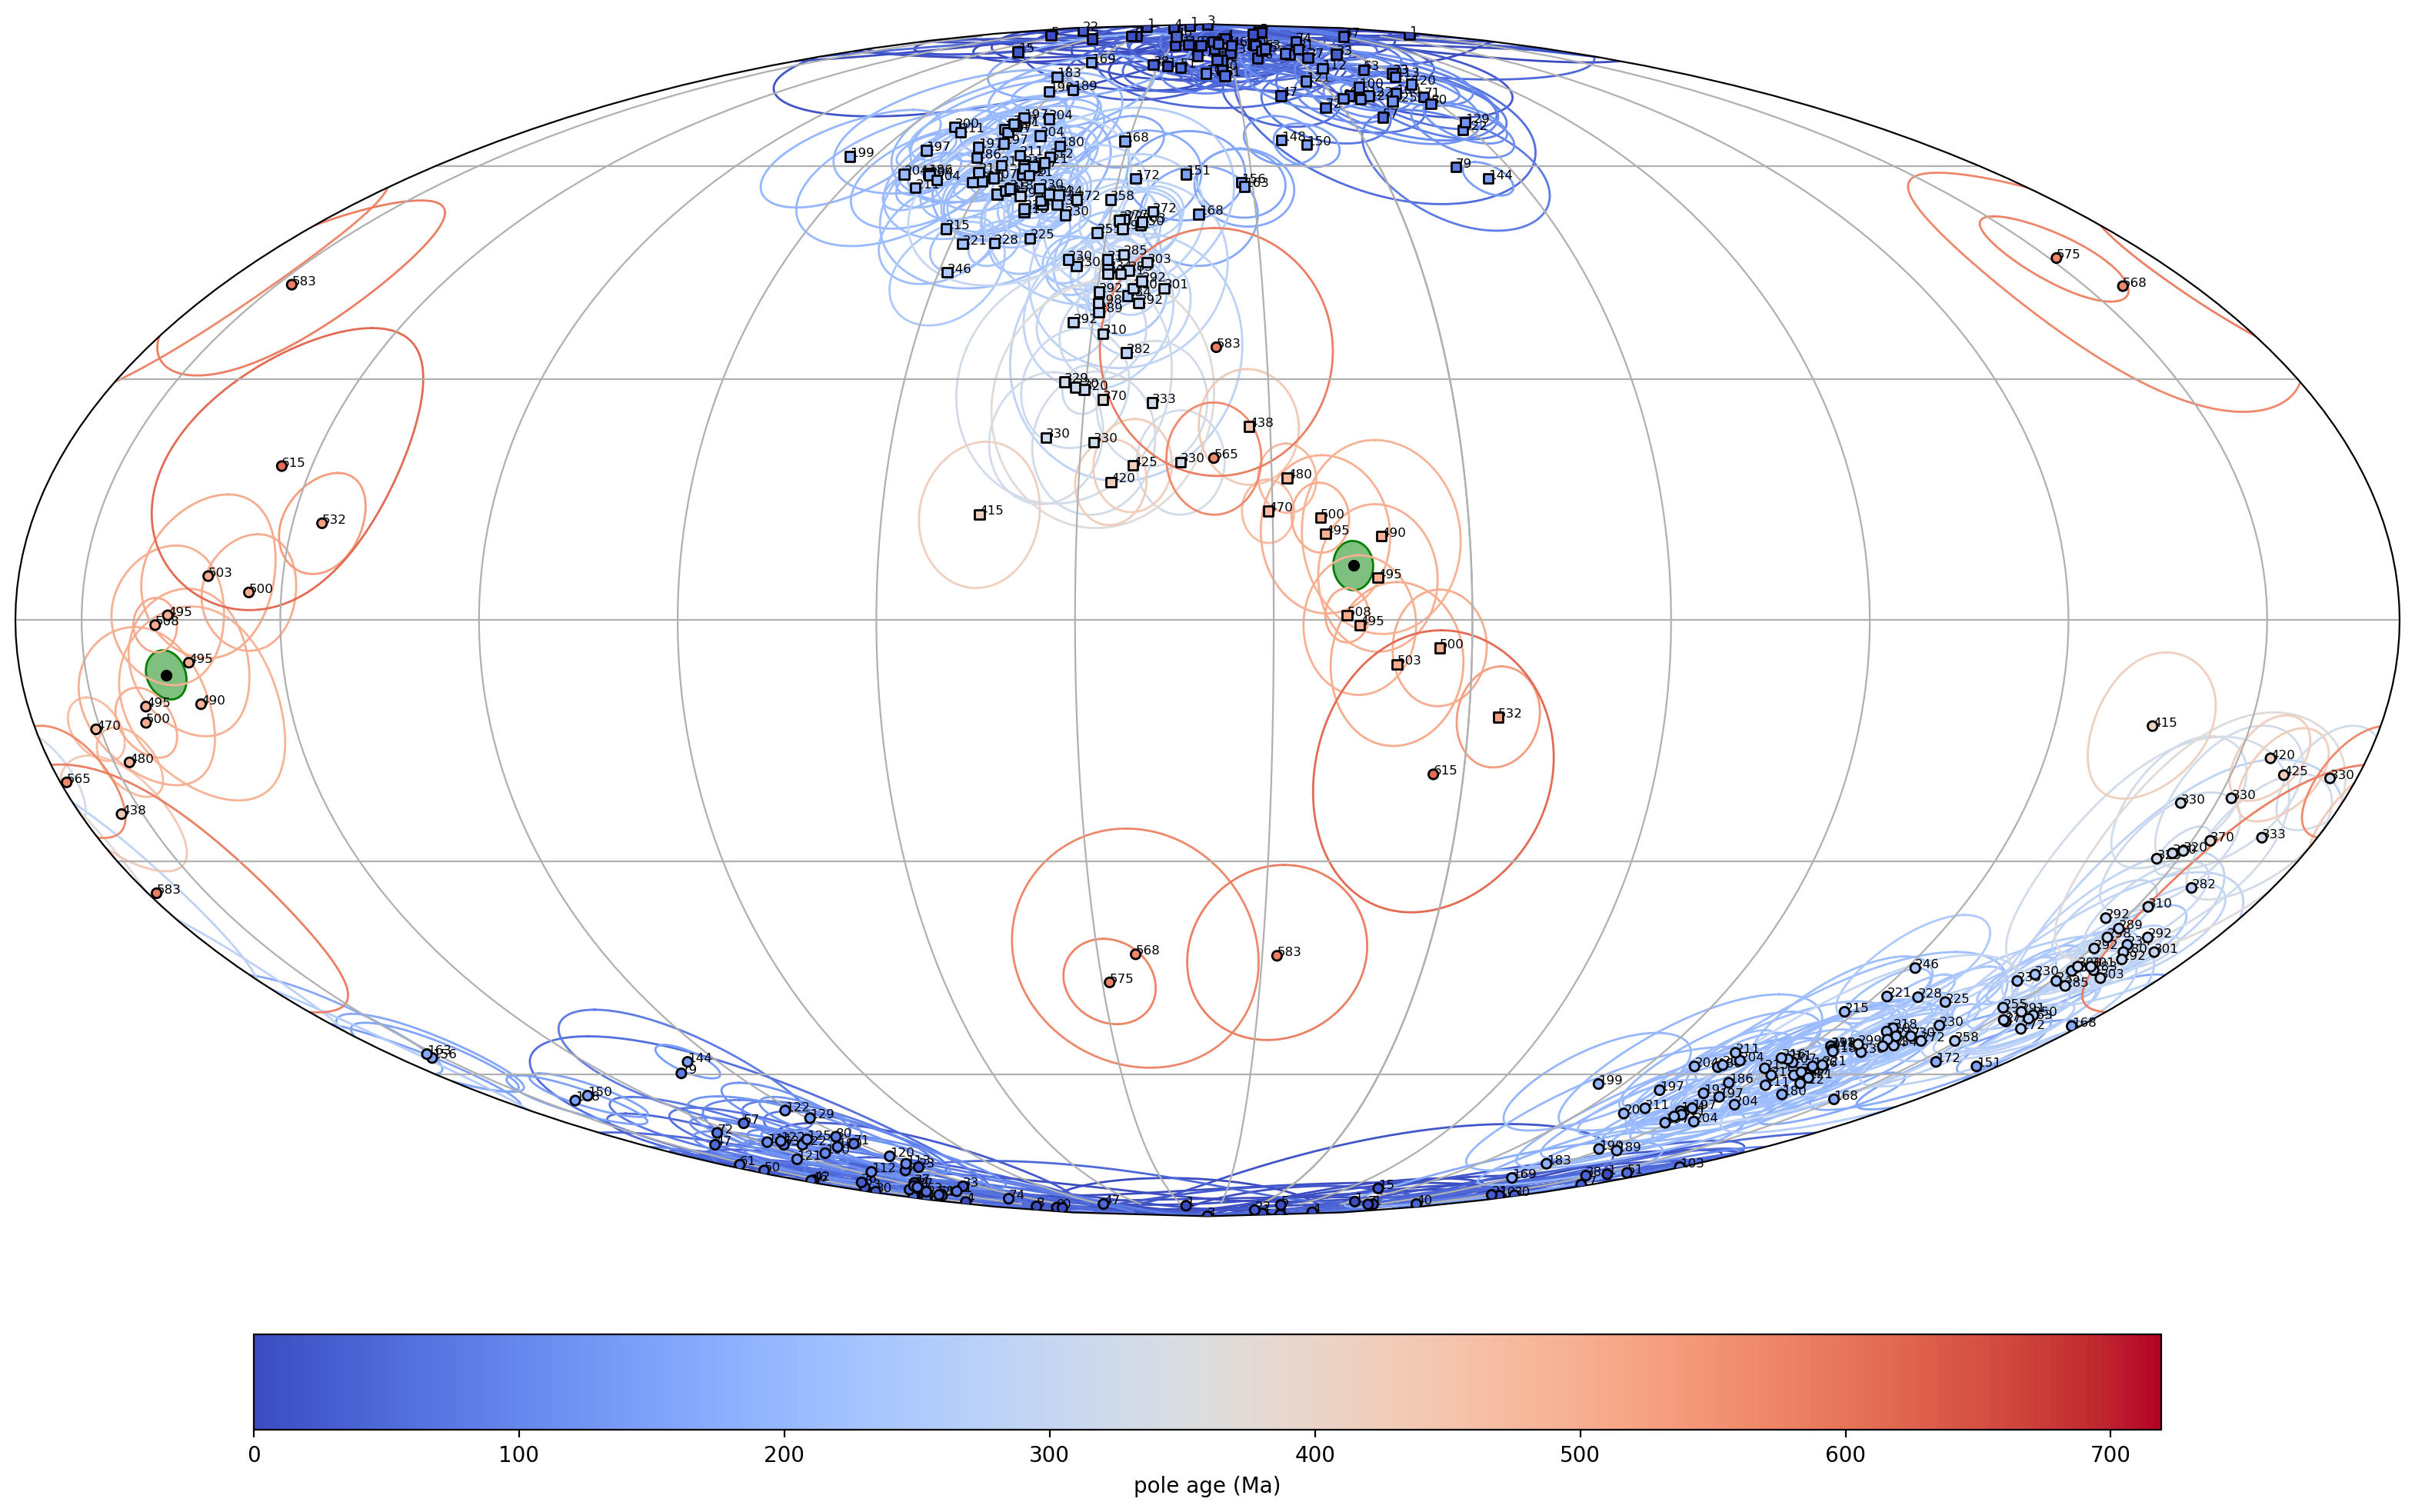

In [6]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Franklin event grand mean',
                     Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=719)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | The Franklin main pulse is tightly dated by high-precision U-Pb CA-ID-TIMS zircon to *ca.* 719.86 ± 0.21 – 718.61 ± 0.30 Ma (Pu et al., 2022), corroborated by Dufour et al. (2023) and synthesized by Macdonald & Swanson-Hysell (2023); these supersede the older baddeleyite ages (*ca.* 723–712 Ma; Heaman et al., 1992; Denyszyn et al., 2009). The pole's age is constrained well within ± 15 Ma. |
| 2 | Techniques and statistical analysis | **1** | Stepwise AF and thermal demagnetization with principal-component analysis; the grand mean combines site-filtered results from multiple studies (B = 56) with A95 = 3.0° (Van der Voo Q = 6; Denyszyn et al., 2009). A full site-level R2(c) PSV assessment is deferred to a future site-level rebuild. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by magnetite / low-Ti titanomagnetite, characterized across the constituent studies (Denyszyn et al., 2009, and references therein). |
| 4 | Field tests constrain age of magnetization | **1** | Positive baked-contact test (code C): the characteristic Franklin dyke direction is recorded in the baked Paleoproterozoic host rock but not in the distal unbaked host (Denyszyn et al., 2009), demonstrating a primary thermoremanence. |
| 5 | Structural control / tectonic coherence | **1** | Dykes, sills, and flood basalts of the autochthonous Laurentian craton; near-vertical dykes require no tilt correction. (The grand mean restores documented Cenozoic block rotations in the Nares Strait region.) |
| 6 | Presence of reversals | **1** | The Franklin remanence is dual-polarity (normal and reverse site results in roughly equal number), recording at least one geomagnetic reversal. |
| 7 | No resemblance to younger poles | **1** | The pole's low-latitude position overlaps the Ediacaran–Cambrian segment of the Laurentia APWP, but the positive baked-contact test (R4) independently constrains the magnetization to be primary and *ca.* 719 Ma, satisfying R7 per Meert et al. (2020). |
| | **Total R-score** | **7/7** | |

## Nordic workshop ranking

The prior Nordic Workshop compilation lists this pole as the "Franklin event
grand mean" (Denyszyn et al., 2009) with an 'A' ranking and R-score 7/7. Adopting
the high-precision U-Pb zircon geochronology of Pu et al. (2022) and Dufour et
al. (2023) refines the age constraints. 

In [7]:
# Hard-coded grand mean -> a one-row sites frame supplies the tilt flag and the
# (synthetic) sample count expected by make_nordic_summary.
sites_df = pd.DataFrame({'dir_tilt_correction': [0], 'dir_n_samples': [N_samples]})

Franklin_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Franklin event grand mean',
    sites=sites_df,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Combined result (grand mean; magnetite / low-Ti titanomagnetite remanence)',
    tests='C+ (positive baked contact test; Denyszyn et al., 2009)',
    percent_reversed='MIXED',
    demag_code=4,
    f_factor=1,
    pole_mean_unflattened=None,
    R1=1,
    R2=1,
    R3=1,
    R4=1,
    R5=1,
    R6=1,
    R7=1,
    Grade='A',
    nominal_age=719,
    lomagage=718,
    himagage=720,
    REF_method='Grand-mean pole of Denyszyn et al. (2009) (D+09can; 6.7°N, 162.1°E, A95 3.0). Age updated to ca. 719 Ma from high-precision U-Pb CA-ID-TIMS zircon dates: main-pulse 719.86 ± 0.21 to 718.61 ± 0.30 Ma (Pu et al., 2022) corroborated by Dufour et al. (2023); synthesized by Macdonald & Swanson-Hysell (2023). Supersedes older baddeleyite ages (Heaman et al., 1992).',
    POLE_AUTHORS='Denyszyn, S. W., Halls, H. C., Davis, D. W., & Evans, D. A. D.',
    YEAR=2009,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME=46,
    VPAGES='689-705',
    TITLE='Paleomagnetism and U-Pb geochronology of Franklin dykes in High Arctic Canada and Greenland: a revised age and paleomagnetic pole constraining block rotations in the Nares Strait region',
    COMMENT='Grand-mean pole hard-coded from Denyszyn et al. (2009) Table 3 (D+09can; B=56 site results, synthetic N=1000); not rebuilt from site level. Geochronology updated with Pu et al. (2022) and Dufour et al. (2023).'
)
Franklin_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Franklin event grand mean,,Combined result (grand mean; magnetite / low-T...,C+ (positive baked contact test; Denyszyn et a...,0,73.0,275.4,56,1000,...,720.0,Grand-mean pole of Denyszyn et al. (2009) (D+0...,Franklin event grand mean,"Denyszyn, S. W., Halls, H. C., Davis, D. W., &...",2009,Canadian Journal of Earth Sciences,46,689-705,Paleomagnetism and U-Pb geochronology of Frank...,Grand-mean pole hard-coded from Denyszyn et al...


In [8]:
# save the summary as a single-row CSV in data/nordic_summaries
pt.save_nordic_summary(Franklin_summary, '719_Franklin_LIP')

'../data/nordic_summaries/719_Franklin_LIP.csv'